In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
col_names=["user_id","item_id","rating","timestamp"]
path="./Recommend.csv"
df=pd.read_csv(path,names=col_names)
df.head(10)

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
5,298,474,4,884182806
6,115,265,2,881171488
7,253,465,5,891628467
8,305,451,3,886324817
9,6,86,3,883603013


In [3]:
df.columns

Index(['user_id', 'item_id', 'rating', 'timestamp'], dtype='object')

In [4]:
df.shape

(100000, 4)

In [5]:
df.nunique()

user_id        943
item_id       1682
rating           5
timestamp    49282
dtype: int64

In [6]:
df1=pd.read_csv("./Movie_Id_Titles.csv")
df1.head(20)

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)
5,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...
6,7,Twelve Monkeys (1995)
7,8,Babe (1995)
8,9,Dead Man Walking (1995)
9,10,Richard III (1995)


In [55]:
data=pd.merge(df,df1,on="item_id")
data.head(20)

,user_id,item_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)
5,298,474,4,884182806,Dr. Strangelove or: How I Learned to Stop Worr...
6,115,265,2,881171488,"Hunt for Red October, The (1990)"
7,253,465,5,891628467,"Jungle Book, The (1994)"
8,305,451,3,886324817,Grease (1978)
9,6,86,3,883603013,"Remains of the Day, The (1993)"


In [8]:
data.groupby("title")["rating"].mean().sort_values(ascending=False).head(10)

title
They Made Me a Criminal (1939)                       5.0
Marlene Dietrich: Shadow and Light (1996)            5.0
Saint of Fort Washington, The (1993)                 5.0
Someone Else's America (1995)                        5.0
Star Kid (1997)                                      5.0
Great Day in Harlem, A (1994)                        5.0
Aiqing wansui (1994)                                 5.0
Santa with Muscles (1996)                            5.0
Prefontaine (1997)                                   5.0
Entertaining Angels: The Dorothy Day Story (1996)    5.0
Name: rating, dtype: float64

In [9]:
data.groupby("title")["rating"].count().sort_values(ascending=False).head()

title
Star Wars (1977)             583
Contact (1997)               509
Fargo (1996)                 508
Return of the Jedi (1983)    507
Liar Liar (1997)             485
Name: rating, dtype: int64

In [10]:
rating=pd.DataFrame(data.groupby("title")["rating"].mean())
rating["num_of_rating"]=pd.DataFrame(data.groupby("title")["rating"].count())
rating.sort_values("num_of_rating",ascending=False).head()

,rating,num_of_rating
title,,
Star Wars (1977),4.358491,583
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485


In [11]:
data.groupby("title")["rating"].agg(["mean","count"]).rename(columns={"count":"num_of_rating","mean":"rating"})

,rating,num_of_rating
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41
...,...,...
Young Guns II (1990),2.772727,44
"Young Poisoner's Handbook, The (1995)",3.341463,41
Zeus and Roxanne (1997),2.166667,6


In [12]:
sns.set_style("white")
plt.rcParams["font.size"]=14
plt.rcParams["axes.grid"]=True
plt.rcParams["figure.figsize"]=(12,5)

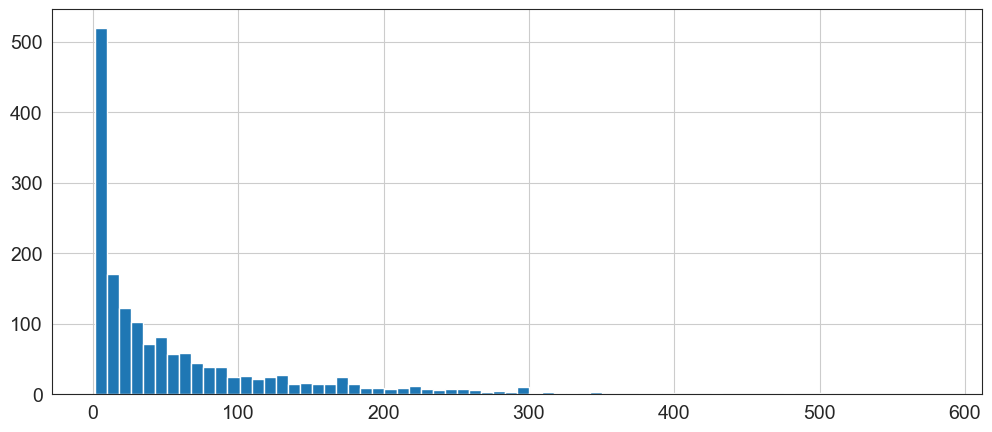

In [13]:
rating["num_of_rating"].hist(bins=70)
plt.show()

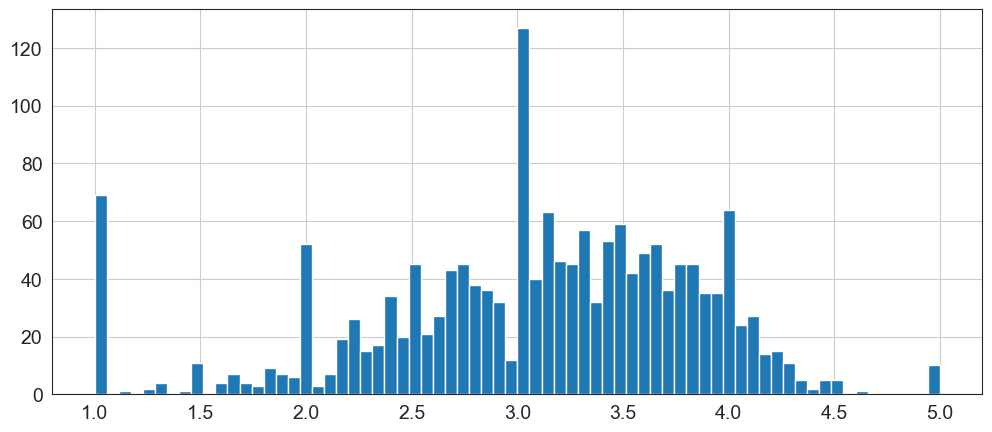

In [14]:
rating["rating"].hist(bins=70)
plt.show()

In [15]:
data.head()

,user_id,item_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [16]:
data.drop('timestamp',inplace=True,axis=1)

In [17]:
data.head()

,user_id,item_id,rating,title
0,196,242,3,Kolya (1996)
1,186,302,3,L.A. Confidential (1997)
2,22,377,1,Heavyweights (1994)
3,244,51,2,Legends of the Fall (1994)
4,166,346,1,Jackie Brown (1997)


In [18]:
moviemat=data.pivot_table(index="user_id",columns="title",values="rating")
moviemat.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,4.0,NaN


In [19]:
moviemat.fillna('0',inplace=True)

C:\Users\bhara\AppData\Local\Temp\ipykernel_14680\1498491588.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  moviemat.fillna('0',inplace=True)


In [56]:
moviemat.head(10)

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,2.0,5.0,0.0,0.0,3.0,4.0,0.0,0.0,...,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0
6,0.0,0.0,0.0,4.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,4.0,0.0,0.0,5.0,5.0,0.0,4.0,...,0.0,0.0,0.0,5.0,3.0,0.0,3.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
rating.sort_values("num_of_rating",ascending=False).head(5)

,rating,num_of_rating
title,,
Star Wars (1977),4.358491,583
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485


In [22]:
moviemat['Toy Story (1995)']

user_id
1      5.0
2      4.0
3        0
4        0
5      4.0
      ... 
939      0
940      0
941    5.0
942      0
943      0
Name: Toy Story (1995), Length: 943, dtype: object

In [71]:
#corelation of similar movie:
movie=moviemat["Top Gun (1986)"]
movie.head()

user_id
1    4.0
2    0.0
3    0.0
4    0.0
5    0.0
Name: Top Gun (1986), dtype: float64

In [211]:
similar_movies=moviemat.corrwith(movie)
m = similar_movies.sort_values(ascending=False).head(20)
m

title
Top Gun (1986)                                1.000000
Jurassic Park (1993)                          0.653495
True Lies (1994)                              0.634587
Speed (1994)                                  0.624709
Die Hard: With a Vengeance (1995)             0.617195
Batman (1989)                                 0.597288
Die Hard 2 (1990)                             0.583404
Star Trek IV: The Voyage Home (1986)          0.573418
Clear and Present Danger (1994)               0.570065
GoldenEye (1995)                              0.553483
Star Trek III: The Search for Spock (1984)    0.541792
Hunt for Red October, The (1990)              0.538076
Terminator, The (1984)                        0.537169
Terminator 2: Judgment Day (1991)             0.533663
Back to the Future (1985)                     0.533240
Star Trek: The Wrath of Khan (1982)           0.529186
Mrs. Doubtfire (1993)                         0.527441
Forrest Gump (1994)                           0.525408
Star

In [73]:
movie_data=pd.DataFrame(similar_movies,columns=["correlation"])
mm = movie_data.sort_values(by='correlation',ascending=False).head(6)
mm

,correlation
title,
Top Gun (1986),1.000000
Jurassic Park (1993),0.653495
True Lies (1994),0.634587
Speed (1994),0.624709
Die Hard: With a Vengeance (1995),0.617195
Batman (1989),0.597288


# 1 Recommendation by similar movies with high correlation

In [212]:
def recommendationEngine(movieName):
    similar_movies=moviemat.corrwith(moviemat[movieName])
    top_similar_movies = similar_movies.sort_values(ascending=False).head(15)
    for i in top_similar_movies.index:
        print(i)
    # for i in range(0,15):
    #     print(top_similar_movies.index[i])

In [213]:
recommendationEngine('Top Gun (1986)')

Top Gun (1986)
Jurassic Park (1993)
True Lies (1994)
Speed (1994)
Die Hard: With a Vengeance (1995)
Batman (1989)
Die Hard 2 (1990)
Star Trek IV: The Voyage Home (1986)
Clear and Present Danger (1994)
GoldenEye (1995)
Star Trek III: The Search for Spock (1984)
Hunt for Red October, The (1990)
Terminator, The (1984)
Terminator 2: Judgment Day (1991)
Back to the Future (1985)


In [74]:
rating=movie_data.join(rating["num_of_rating"])
rating.head()

,correlation,num_of_rating
title,,
'Til There Was You (1997),0.125186,9
1-900 (1994),-0.020995,5
101 Dalmatians (1996),0.211373,109
12 Angry Men (1957),0.210138,125
187 (1997),0.016758,41


In [75]:
top = rating[rating["num_of_rating"]>=400].sort_values(by="correlation",ascending=False).head(5)
top

,correlation,num_of_rating
title,,
Raiders of the Lost Ark (1981),0.520717,420
Independence Day (ID4) (1996),0.390907,429
Return of the Jedi (1983),0.363485,507
Star Wars (1977),0.319905,583
Toy Story (1995),0.277699,452


# Recommendation by usering rating

In [30]:
# def recommendEngine(movieName):
#     similar_movie = moviemat.corrwith(moviemat[movieName])
#     movies_data = pd.DataFrame(similar_movies,columns=["correlation"])
#     ratings_data = movies_data.join(rating["num_of_rating"])
#     top_similar_movies = ratings_data[ratings_data["num_of_rating"]>=400].sort_values(by="correlation",ascending=False).head(10)
#     # return top_similar_movies
    
#     for i in range(0,6):
#         print(top_similar_movies.index[i])

In [69]:
# recommendEngine('Speed (1994)')

Return of the Jedi (1983)
Star Wars (1977)
Raiders of the Lost Ark (1981)
Independence Day (ID4) (1996)
Toy Story (1995)
Godfather, The (1972)


# with using knn

In [ ]:
# recommending movies by rating for users which are not seen 

In [53]:

moviemat

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,2.0,5.0,0.0,0.0,3.0,4.0,0.0,0.0,...,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
940,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
941,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [167]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

In [168]:
# before scaling , 
x = moviemat  
y = moviemat  

xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

knn_regressor = KNeighborsRegressor(n_neighbors=5, metric='cosine')
knn_regressor.fit(xtrain,ytrain)


KNeighborsRegressor(metric='cosine')

In [178]:
# here we have users rating every movie 
user_index = 2
moviemat.loc[user_index].values

array([0., 0., 0., ..., 0., 0., 0.])

In [179]:
user_data = moviemat.loc[user_index].values.reshape(1, -1)
user_data

array([[0., 0., 0., ..., 0., 0., 0.]])

In [142]:
# predicting the rating 
predicted_ratings = knn_regressor.predict(user_data)[0]
predicted_ratings

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([0., 0., 0., ..., 0., 0., 0.])

In [143]:
predicted_ratings_series = pd.Series(predicted_ratings, index=moviemat.columns)
predicted_ratings_series

title
'Til There Was You (1997)                0.0
1-900 (1994)                             0.0
101 Dalmatians (1996)                    0.0
12 Angry Men (1957)                      0.0
187 (1997)                               0.0
                                        ... 
Young Guns II (1990)                     0.0
Young Poisoner's Handbook, The (1995)    0.0
Zeus and Roxanne (1997)                  0.0
unknown                                  0.0
Á köldum klaka (Cold Fever) (1994)       0.0
Length: 1664, dtype: float64

In [144]:
moviemat.columns

Index([''Til There Was You (1997)', '1-900 (1994)', '101 Dalmatians (1996)',
       '12 Angry Men (1957)', '187 (1997)', '2 Days in the Valley (1996)',
       '20,000 Leagues Under the Sea (1954)', '2001: A Space Odyssey (1968)',
       '3 Ninjas: High Noon At Mega Mountain (1998)', '39 Steps, The (1935)',
       ...
       'Yankee Zulu (1994)', 'Year of the Horse (1997)', 'You So Crazy (1994)',
       'Young Frankenstein (1974)', 'Young Guns (1988)',
       'Young Guns II (1990)', 'Young Poisoner's Handbook, The (1995)',
       'Zeus and Roxanne (1997)', 'unknown',
       'Á köldum klaka (Cold Fever) (1994)'],
      dtype='object', name='title', length=1664)

In [145]:
# checking if user didn't watch any movie or rated the movie
moviemat.loc[user_index] == 0

title
'Til There Was You (1997)                True
1-900 (1994)                             True
101 Dalmatians (1996)                    True
12 Angry Men (1957)                      True
187 (1997)                               True
                                         ... 
Young Guns II (1990)                     True
Young Poisoner's Handbook, The (1995)    True
Zeus and Roxanne (1997)                  True
unknown                                  True
Á köldum klaka (Cold Fever) (1994)       True
Name: 2, Length: 1664, dtype: bool

In [146]:
unseen_movies = moviemat.columns[moviemat.loc[user_index] == 0]
unseen_movies

Index([''Til There Was You (1997)', '1-900 (1994)', '101 Dalmatians (1996)',
       '12 Angry Men (1957)', '187 (1997)', '2 Days in the Valley (1996)',
       '20,000 Leagues Under the Sea (1954)', '2001: A Space Odyssey (1968)',
       '39 Steps, The (1935)', '8 1/2 (1963)',
       ...
       'Yankee Zulu (1994)', 'Year of the Horse (1997)', 'You So Crazy (1994)',
       'Young Frankenstein (1974)', 'Young Guns (1988)',
       'Young Guns II (1990)', 'Young Poisoner's Handbook, The (1995)',
       'Zeus and Roxanne (1997)', 'unknown',
       'Á köldum klaka (Cold Fever) (1994)'],
      dtype='object', name='title', length=1603)

In [147]:
recommended_movies = predicted_ratings_series[unseen_movies].sort_values(ascending=False).head(10)
recommended_movies

title
Amistad (1997)                 3.0
Lone Star (1996)               2.8
Michael Collins (1996)         2.2
Boot, Das (1981)               2.0
Big Night (1996)               1.8
Game, The (1997)               1.6
Spitfire Grill, The (1996)     1.6
Dead Man Walking (1995)        1.6
Seven Years in Tibet (1997)    1.6
That Thing You Do! (1996)      1.4
dtype: float64

In [180]:
# function 
def rS(user):
    user_data = moviemat.loc[user].values.reshape(1, -1)
    predicted_ratings = knn_regressor.predict(user_data)[0]
    predicted_ratings_data = pd.Series(predicted_ratings, index=moviemat.columns)
    user_unseen_movies = moviemat.columns[moviemat.loc[user_index] == 0]
    recommend_movies = predicted_ratings_data[user_unseen_movies].sort_values(ascending=False).head(10)
    return recommend_movies
    

In [181]:
rS(35)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


title
Volcano (1997)              4.0
G.I. Jane (1997)            3.8
Saint, The (1997)           3.8
Game, The (1997)            3.4
Conspiracy Theory (1997)    3.4
Kiss the Girls (1997)       3.2
Murder at 1600 (1997)       2.8
Picture Perfect (1997)      2.4
Devil's Own, The (1997)     2.4
Money Talks (1997)          2.4
dtype: float64

# 2 recommending similar movies using knn

In [171]:
moviemat

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,2.0,5.0,0.0,0.0,3.0,4.0,0.0,0.0,...,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
940,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
941,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [172]:
# taking movies as index by using transpose method
transpose_mat = moviemat.T
transpose_mat

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
title,,,,,,,,,,,,,,,,,,,,,
'Til There Was You (1997),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1-900 (1994),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101 Dalmatians (1996),2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0
12 Angry Men (1957),5.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
187 (1997),0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Young Guns II (1990),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
"Young Poisoner's Handbook, The (1995)",0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zeus and Roxanne (1997),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [173]:
from sklearn.preprocessing import StandardScaler

In [175]:
scaler = StandardScaler()
moviemat_scaled = scaler.fit_transform(transpose_mat)
moviemat_scaled_df = pd.DataFrame(moviemat_scaled, index = transpose_mat.index, columns = transpose_mat.columns)
moviemat_scaled_df

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
title,,,,,,,,,,,,,,,,,,,,,
'Til There Was You (1997),-0.412003,-0.187692,-0.165868,-0.118422,-0.306650,-0.361406,-0.538451,-0.182049,-0.113159,-0.348873,...,-0.328357,-0.151252,-0.293836,-0.145569,-0.245340,-0.168473,-0.251014,-0.113084,-0.218162,-0.312407
1-900 (1994),-0.412003,-0.187692,-0.165868,-0.118422,-0.306650,-0.361406,-0.538451,-0.182049,-0.113159,-0.348873,...,-0.328357,-0.151252,-0.293836,-0.145569,-0.245340,-0.168473,-0.251014,-0.113084,-0.218162,-0.312407
101 Dalmatians (1996),0.991422,-0.187692,-0.165868,-0.118422,1.722239,-0.361406,-0.538451,-0.182049,-0.113159,-0.348873,...,1.380433,-0.151252,-0.293836,3.552558,4.380669,-0.168473,-0.251014,-0.113084,-0.218162,-0.312407
12 Angry Men (1957),3.096559,-0.187692,-0.165868,-0.118422,-0.306650,2.816294,1.717011,-0.182049,-0.113159,3.401282,...,-0.328357,-0.151252,-0.293836,-0.145569,-0.245340,-0.168473,-0.251014,-0.113084,-0.218162,-0.312407
187 (1997),-0.412003,-0.187692,3.589299,-0.118422,-0.306650,-0.361406,-0.538451,-0.182049,-0.113159,-0.348873,...,-0.328357,-0.151252,-0.293836,-0.145569,-0.245340,-0.168473,-0.251014,-0.113084,-0.218162,-0.312407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Young Guns II (1990),-0.412003,-0.187692,-0.165868,-0.118422,-0.306650,-0.361406,-0.538451,-0.182049,-0.113159,-0.348873,...,-0.328357,-0.151252,-0.293836,-0.145569,-0.245340,-0.168473,-0.251014,-0.113084,-0.218162,2.409297
"Young Poisoner's Handbook, The (1995)",-0.412003,-0.187692,-0.165868,-0.118422,-0.306650,-0.361406,1.153146,-0.182049,-0.113159,-0.348873,...,-0.328357,-0.151252,4.336304,-0.145569,-0.245340,-0.168473,-0.251014,-0.113084,-0.218162,-0.312407
Zeus and Roxanne (1997),-0.412003,-0.187692,-0.165868,-0.118422,-0.306650,-0.361406,-0.538451,-0.182049,-0.113159,-0.348873,...,-0.328357,-0.151252,-0.293836,-0.145569,-0.245340,-0.168473,-0.251014,-0.113084,-0.218162,-0.312407


In [176]:
x = moviemat_scaled_df 
y = moviemat_scaled_df

model2 = KNeighborsRegressor(n_neighbors=5, metric='cosine')
model2.fit(x, y)

KNeighborsRegressor(metric='cosine')

In [183]:
movie_title = 'Top Gun (1986)'

In [184]:
moviemat_scaled_df.loc[movie_title].values.reshape(1, -1)

array([[ 2.39484644, -0.18769236, -0.16586827, -0.11842184, -0.30664992,
        -0.3614061 ,  1.15314577, -0.18204861, -0.11315909,  2.65125111,
        -0.33599496,  6.32747215,  2.19818309, -0.24212579, -0.23139919,
         3.74241204, -0.12264516, -0.434624  , -0.10753639, -0.16148036,
        -0.30639644,  3.80514032,  1.5420075 , -0.20271582, -0.21910742,
        -0.25114994, -0.11929541, -0.21440346, -0.14040091,  6.31144947,
        -0.14439273, -0.15148445, -0.11709733, -0.10450099, -0.11299607,
        -0.10472016,  7.08415691,  4.47547917, -0.11254354, -0.13909273,
        -0.17557537,  2.94763629,  2.6724346 ,  3.36461804, -0.16698787,
        -0.125303  , -0.11992562, -0.19418341,  0.65087648, -0.110274  ,
        -0.11238023, -0.18393243, -0.12736877, -0.19237094, -0.10329816,
         3.01238301, -0.24973484, -0.30153881,  1.21136027,  2.54740188,
        -0.10446359, -0.37834344, -0.23002947,  2.11294061, -0.21899478,
        -0.14655381, -0.13186267, -0.12775587, -0.1

In [185]:
movie_vector = moviemat_scaled_df.loc[movie_title].values.reshape(1, -1)

In [219]:
# here we used kneighbors for near neighbors i also don't know
similar_movies = model2.kneighbors(movie_vector, n_neighbors=10, return_distance=True)
similar_movies

(array([[2.22044605e-16, 3.94238041e-01, 4.56073156e-01, 4.58047842e-01,
         4.59070285e-01, 4.74022983e-01, 5.00328213e-01, 5.11341438e-01,
         5.13561329e-01, 5.30821873e-01]]),
 array([[1516,  797,  416, 1373, 1533,  132,  415, 1391,  312,  616]],
       dtype=int64))

In [202]:
movie_indices = similar_movies[1][0][1:]  
movie_indices

array([ 797,  416, 1373, 1533,  132,  415, 1391,  312,  616], dtype=int64)

In [227]:
distances = similar_movies[0][0][1:]
distances

array([0.39423804, 0.45607316, 0.45804784, 0.45907028, 0.47402298,
       0.50032821, 0.51134144, 0.51356133, 0.53082187])

In [229]:
moviemat_scaled_df.iloc[movie_indices]

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
title,,,,,,,,,,,,,,,,,,,,,
Jurassic Park (1993),3.096559,-0.187692,-0.165868,-0.118422,-0.306650,-0.361406,1.153146,6.579757,-0.113159,2.651251,...,3.089223,-0.151252,-0.293836,-0.145569,-0.24534,-0.168473,4.264531,-0.113084,-0.218162,-0.312407
Die Hard: With a Vengeance (1995),-0.412003,-0.187692,-0.165868,-0.118422,-0.306650,-0.361406,1.717011,3.875035,-0.113159,-0.348873,...,3.089223,-0.151252,-0.293836,-0.145569,-0.24534,-0.168473,-0.251014,-0.113084,-0.218162,-0.312407
Speed (1994),-0.412003,-0.187692,-0.165868,-0.118422,-0.306650,-0.361406,2.280877,5.227396,-0.113159,-0.348873,...,-0.328357,-0.151252,-0.293836,-0.145569,-0.24534,-0.168473,3.135645,-0.113084,-0.218162,2.409297
True Lies (1994),-0.412003,-0.187692,-0.165868,-0.118422,3.751127,-0.361406,2.280877,1.170313,9.902625,2.651251,...,-0.328357,-0.151252,-0.293836,-0.145569,-0.24534,-0.168473,-0.251014,-0.113084,-0.218162,3.316532
Batman (1989),-0.412003,-0.187692,-0.165868,-0.118422,2.736683,-0.361406,1.717011,5.227396,-0.113159,-0.348873,...,3.089223,-0.151252,-0.293836,-0.145569,-0.24534,-0.168473,-0.251014,-0.113084,-0.218162,3.316532
Die Hard 2 (1990),1.693134,-0.187692,-0.165868,-0.118422,2.736683,-0.361406,2.280877,-0.182049,-0.113159,-0.348873,...,3.089223,-0.151252,-0.293836,-0.145569,-0.24534,-0.168473,-0.251014,-0.113084,-0.218162,3.316532
Star Trek IV: The Voyage Home (1986),2.394846,-0.187692,-0.165868,-0.118422,2.736683,-0.361406,1.153146,-0.182049,-0.113159,2.651251,...,-0.328357,-0.151252,-0.293836,-0.145569,-0.24534,-0.168473,-0.251014,-0.113084,-0.218162,0.594828
Clear and Present Danger (1994),-0.412003,-0.187692,-0.165868,-0.118422,-0.306650,-0.361406,1.717011,3.875035,-0.113159,-0.348873,...,-0.328357,-0.151252,-0.293836,-0.145569,-0.24534,-0.168473,-0.251014,-0.113084,-0.218162,3.316532
GoldenEye (1995),1.693134,-0.187692,-0.165868,-0.118422,2.736683,-0.361406,-0.538451,-0.182049,-0.113159,-0.348873,...,3.089223,-0.151252,-0.293836,-0.145569,-0.24534,-0.168473,-0.251014,-0.113084,-0.218162,4.223767


In [207]:
moviemat_scaled_df.iloc[movie_indices].index

Index(['Jurassic Park (1993)', 'Die Hard: With a Vengeance (1995)',
       'Speed (1994)', 'True Lies (1994)', 'Batman (1989)',
       'Die Hard 2 (1990)', 'Star Trek IV: The Voyage Home (1986)',
       'Clear and Present Danger (1994)', 'GoldenEye (1995)'],
      dtype='object', name='title')

In [205]:
similar_movie_titles = moviemat_scaled_df.iloc[movie_indices].index
similar_movie_titles

Index(['Jurassic Park (1993)', 'Die Hard: With a Vengeance (1995)',
       'Speed (1994)', 'True Lies (1994)', 'Batman (1989)',
       'Die Hard 2 (1990)', 'Star Trek IV: The Voyage Home (1986)',
       'Clear and Present Danger (1994)', 'GoldenEye (1995)'],
      dtype='object', name='title')

In [228]:
recommendations = pd.DataFrame({
        "Movie": similar_movie_titles,
        "Similarity Score": 1 - distances  # Convert distance to similarity
    }).sort_values(by="Similarity Score", ascending=False)
recommendations

,Movie,Similarity Score
0,Jurassic Park (1993),0.605762
1,Die Hard: With a Vengeance (1995),0.543927
2,Speed (1994),0.541952
3,True Lies (1994),0.540930
4,Batman (1989),0.525977
5,Die Hard 2 (1990),0.499672
6,Star Trek IV: The Voyage Home (1986),0.488659
7,Clear and Present Danger (1994),0.486439
8,GoldenEye (1995),0.469178


In [238]:
def similar_movies_recommendation(movie_title, n_recommendations=10):
    if movie_title not in moviemat_scaled_df.index:
        return "Movie not found in dataset."
    
    movie_vector = moviemat_scaled_df.loc[movie_title].values.reshape(1, -1)
    
    similar_movies = model2.kneighbors(movie_vector, n_neighbors=n_recommendations + 1, return_distance=True)
    
    movie_indices = similar_movies[1][0][1:]  
    distances = similar_movies[0][0][1:]
    

    similar_movie_titles = moviemat_scaled_df.iloc[movie_indices].index
    
    recommendations = pd.DataFrame({
        "Movie": similar_movie_titles,
        "Similarity Score": 1 - distances  
    }).sort_values(by="Similarity Score", ascending=False)
    
    for i in recommendations.Movie:
        print(i)


print(similar_movies_recommendation('Jurassic Park (1993)'))

Top Gun (1986)
Speed (1994)
Empire Strikes Back, The (1980)
True Lies (1994)
Raiders of the Lost Ark (1981)
Indiana Jones and the Last Crusade (1989)
Batman (1989)
Star Trek: The Wrath of Khan (1982)
Aladdin (1992)
Lion King, The (1994)
None


In [ ]:
# 1 and 2 are similar methods